<table>
    <tr>
        <td><img src="https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/Logo_EICT_horizontal_ESPANOL%20(1).png" width="300"/></td>
        <td>&nbsp;</td>
        <td>
            <h1 style="font-size:200%;color:blue;text-align:center">    <FONT COLOR="blue">  Algoritmo de Grover   </p> listas no estructuradas </FONT>         </h1></td>         
        <td>
            <tp><p style="font-size:99%;text-align:center">Tesis</p></tp>
            <tp><p style="font-size:115%;text-align:center">Maestría ICT 2025-2</p></tp>
            <tp><p style="font-size:115%;text-align:center">Stiven Paloma Alarcon</p></tp>
        </td>
    </tr>
</table>



# <FONT SIZE=5 COLOR="white"> **Aplicación del Algoritmo de Grover en búsquedas no estructuradas: análisis y comparación de la eficiencia de algoritmos de búsqueda con algoritmos cuánticos.** </FONT>

Las búsquedas en bases de datos no estructuradas o listas no ordenadas son un desafío esencial en la teoría de la computación, debido a la ausencia de un orden que permita aprovechar técnicas de optimización clásicas. En este tipo de problemas, la localización de un elemento que cumple una propiedad específica requiere, en el caso clásico, un análisis exhaustivo de los N elementos presentes en la base de datos, lo que implica un costo computacional promedio de O(N). Este límite se mantiene incluso con enfoques avanzados descritos en trabajos fundamentales de autores como Knuth (1998), quien en The Art of Computer Programming analiza a profundidad las técnicas de búsqueda lineal y sus limitaciones en ausencia de estructura (Knuth, 1998). De manera similar, Cormen, Leiserson, Rivest y Stein (2009) subrayan en Introduction to Algorithms que las búsquedas no estructuradas no pueden beneficiarse de optimizaciones derivadas de estructuras jerárquicas, como árboles de búsqueda o tablas hash, destacando que el rendimiento está limitado por la necesidad de inspeccionar cada elemento de manera secuencial. Por otro lado, Sedgewick (2011) y Wirth (1976) abordan estrategias relacionadas con la eficiencia en algoritmos de búsqueda, pero recalcan que los avances en estructuras de datos no eliminan la barrera inherente de O(N) para problemas sin orden. En este contexto, la computación cuántica ofrece una solución innovadora al problema de búsquedas no estructuradas. El Algoritmo de Grover, introducido en 1996, reduce el tiempo de búsqueda a O(√ N), logrando una aceleración cuadrática en comparación con los algoritmos clásicos. Esto se consigue mediante transformaciones iterativas basadas en la superposición cuántica y la interferencia constructiva, lo que amplifica la probabilidad del estado objetivo y atenúa las demás posibilidades (Grover, 1996). Este avance, sin embargo, enfrenta retos en su implementación práctica, como la preservación de la coherencia cuántica, el diseño de oráculos específicos para cada problema y la necesidad de puertas cuánticas de alta fidelidad. Este proyecto se centra en la implementación del Algoritmo Cuántico de Grover, donde se explorará en simulaciones de computación cuántica con apoyo del lenguaje Qiskit, contribuyendo a una comprensión más profunda de cómo estas técnicas pueden resolver problemas fundamentales de búsqueda con mayor eficiencia. El análisis combinado de estas limitaciones clásicas y los avances cuánticos pone de manifiesto el potencial transformador del Algoritmo de Grover para problemas de búsqueda en bases de datos no estructuradas, aportando una perspectiva novedosa que supera los enfoques tradicionales estudiados por autores como Knuth, Cormen et al., Sedgewick y Wirth.




In [1]:
pip install -r requirements.txt

  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---------------------------------------- 2.2/2.2 MB 30.7 MB/s  0:00:00
   ---------------------------------------- 0.0/14.3 MB ? eta -:--:--
   ---------------------- ----------------- 8.1/14.3 MB 38.7 MB/s eta 0:00:01
   ---------------------------------------- 14.3/14.3 MB 37.5 MB/s  0:00:00
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   --------------------------- ------------ 8.4/12.3 MB 40.0 MB/s eta 0:00:01
   ---------------------------------------- 12.3/12.3 MB 36.7 MB/s  0:00:00
Using cached h11-0.16.0-py3-none-any.whl (37 kB)

   --- ------------------------------------  1/12 [qtpy]
   --- ------------------------------------  1/12 [qtpy]
   ------------- --------------------------  4/12 [httpcore]
   ---------------- -----------------------  5/12 [ipywidgets]
   -------------------- -------------------  6/12 [httpx]
  

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
#La usamos para calcular el número optimo de iteraciones de Grover
import math

#Nos permite definir el tipo de dato para las cláusulas de 3-SAT
from typing import List, Tuple

#Nos permite trabajar con matrices y vectores, procesar las probabilidades y graficar resultados
import numpy as np

#Genera números aleatorios
import random

#Se usa para graficar resultados como histogramas, matroces de densidad, entre otros
import matplotlib.pyplot as plt

# QuantumCircuit: para construir tu circuito cuántico (el núcleo de tu algoritmo)
#QuantumRegister: crea registros de qubits (variables, cláusulas, ancillas)
#transpile: adapta el circuito al backend físico, optimizando para restricciones reales
from qiskit import QuantumCircuit, QuantumRegister, transpile

#Función para graficar los resultados de las mediciones del circuito
from qiskit.visualization import plot_histogram

#DensityMatrix: representa estados mixtos (útil después de traza parcial)
#Statevector: representa estados puros del sistema cuántico
#partial_trace: elimina qubits ancilla, quedándose solo con la información de los qubits relevantes (variables en 3-SAT)
from qiskit.quantum_info import DensityMatrix, Statevector, partial_trace

#Implementa una puerta multi-control NOT (Toffoli generalizada)
from qiskit.circuit.library import MCXGate

#Aer: permite usar simuladores cuánticos locales o configurables
#AerSimulator: simulador especializado, configurable con diferentes métodos (statevector, density_matrix, etc.). Fundamental para ejecutar y depurar tu circuito antes de enviarlo a un backend real
from qiskit_aer import Aer
from qiskit_aer import AerSimulator

#Para declarar registros clásicos necesarios para medir y almacenar los resultados del circuito cuántico
from qiskit import ClassicalRegister

#Proporciona una forma moderna de ejecutar circuitos y obtener estadísticas de salida
from qiskit.primitives import Sampler
#Permite conectarse con dispositivos cuánticos reales de IBM, gestiona el acceso con tokens, instancia, elección de backend, ejecución de trabajos reales
from qiskit_ibm_runtime import QiskitRuntimeService

#Para mostrar objetos visuales dentro de notebooks interactivos
from IPython.display import display
# Asegura import si no está
from typing import List 

# Define tipos personalizados para mayor claridad
from typing import Callable

import math
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService, Sampler as SamplerV2
from qiskit.circuit.library import MCMT, ZGate  # AJUSTADO: Import ZGate para MCMT
from qiskit.visualization import plot_histogram
import numpy as np


In [4]:
pip install python-dotenv

  Using cached python_dotenv-1.1.1-py3-none-any.whl.metadata (24 kB)
Using cached python_dotenv-1.1.1-py3-none-any.whl (20 kB)
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [5]:
import os
from dotenv import load_dotenv

## Ejecución del algoritmo

El número óptimo de iteraciones es aproximadamente $\pi/4\sqrt{N}$. Para $N = 2^{20}$ esto equivale a 804 iteraciones. Ejecutamos el circuito en el simulador de Qiskit.

In [6]:
# --- Paso 1: Guardar la cuenta localmente (opcional) ---

load_dotenv()  # Carga variables de entorno desde un archivo .env si existe

QiskitRuntimeService.save_account(
    channel = os.getenv("channel_ibm"),  # usa variable de entorno o valor por defecto
    token   = os.getenv("url_token_ibm"),     # reemplaza con tu token real (cadena larga)
    instance = os.getenv("instance_ibm"),  # reemplaza con tu CRN real
    set_as_default = True,
    overwrite = True
)

# --- Paso 2: Instanciar el servicio (usa la cuenta guardada) ---
service = QiskitRuntimeService()


print("Servicio inicializado correctamente:", service)

# Ver los backends disponibles
print("Backends disponibles:", service.backends())


Servicio inicializado correctamente: <QiskitRuntimeService>
Backends disponibles: [<IBMBackend('ibm_brisbane')>, <IBMBackend('ibm_torino')>]


In [3]:
backend = service.get_backend("ibm_brisbane")
print("Datos del backend:", backend.properties())


Datos del backend: <qiskit.providers.models.backendproperties.BackendProperties object at 0x000001E76D4E0FB0>


In [2]:
# --- Parámetros principales ---
n = 12  # Solo 12 qubits → 25 totales (12+12+1)
N = 2**n
target_number = 1234  # Entre 0 y 4095
shots = 1024
use_real_backend = True
backend_name = "ibm_brisbane"

# --- Iteraciones Grover ---
theta = math.asin(math.sqrt(1 / N))
iterations = math.floor(math.pi / (4 * theta))
print(f"Buscando {target_number} en {N} elementos. Iteraciones: {iterations}")

# --- Registros cuánticos ---
search_reg = QuantumRegister(n, name='search')
target_reg = QuantumRegister(n, name='target')
ancilla = QuantumRegister(1, name='ancilla')
c_reg = ClassicalRegister(n, name='result')
qc = QuantumCircuit(search_reg, target_reg, ancilla, c_reg)

# --- Inicialización ---
target_bits = format(target_number, f'0{n}b')[::-1]
for i, bit in enumerate(target_bits):
    if bit == '1':
        qc.x(target_reg[i])
qc.barrier()
qc.h(search_reg)
qc.x(ancilla)
qc.h(ancilla)
qc.barrier()

# --- Oráculo MCMT ---
def get_oracle():
    oracle_qc = QuantumCircuit(search_reg, target_reg, ancilla, name="Oracle")
    for i in range(n):
        oracle_qc.cx(search_reg[i], target_reg[i])
    oracle_qc.x(target_reg)
    mcm = MCMT(ZGate(), num_ctrl_qubits=n, num_target_qubits=1)
    oracle_qc.append(mcm, target_reg[:] + [ancilla[0]])
    oracle_qc.x(target_reg)
    for i in range(n):
        oracle_qc.cx(search_reg[i], target_reg[i])
    return oracle_qc

# --- Difusor ---
def get_diffuser():
    qc_diff = QuantumCircuit(search_reg, name="Diffuser")
    qc_diff.h(search_reg)
    qc_diff.x(search_reg)
    qc_diff.h(search_reg[-1])
    qc_diff.mcx(search_reg[:-1], search_reg[-1])
    qc_diff.h(search_reg[-1])
    qc_diff.x(search_reg)
    qc_diff.h(search_reg)
    return qc_diff

oracle = get_oracle()
diffuser = get_diffuser()

Buscando 1234 en 4096 elementos. Iteraciones: 50


## 1. Diagrama del Circuito del Oráculo


c:\Users\USUARIO\Desktop\STEVEN ESCRITORIO\UROSARIO\3er SEMESTRE\Tesis\AlgoritmoGR\.tesis\Lib\site-packages\qiskit\visualization\circuit\matplotlib.py:269: UserWarning: Style JSON file 'iqx.json' not found in any of these locations: c:\Users\USUARIO\Desktop\STEVEN ESCRITORIO\UROSARIO\3er SEMESTRE\Tesis\AlgoritmoGR\.tesis\Lib\site-packages\qiskit\visualization\circuit\styles\iqx.json, iqx.json. Will use default style.
  self._style, def_font_ratio = load_style(self._style)


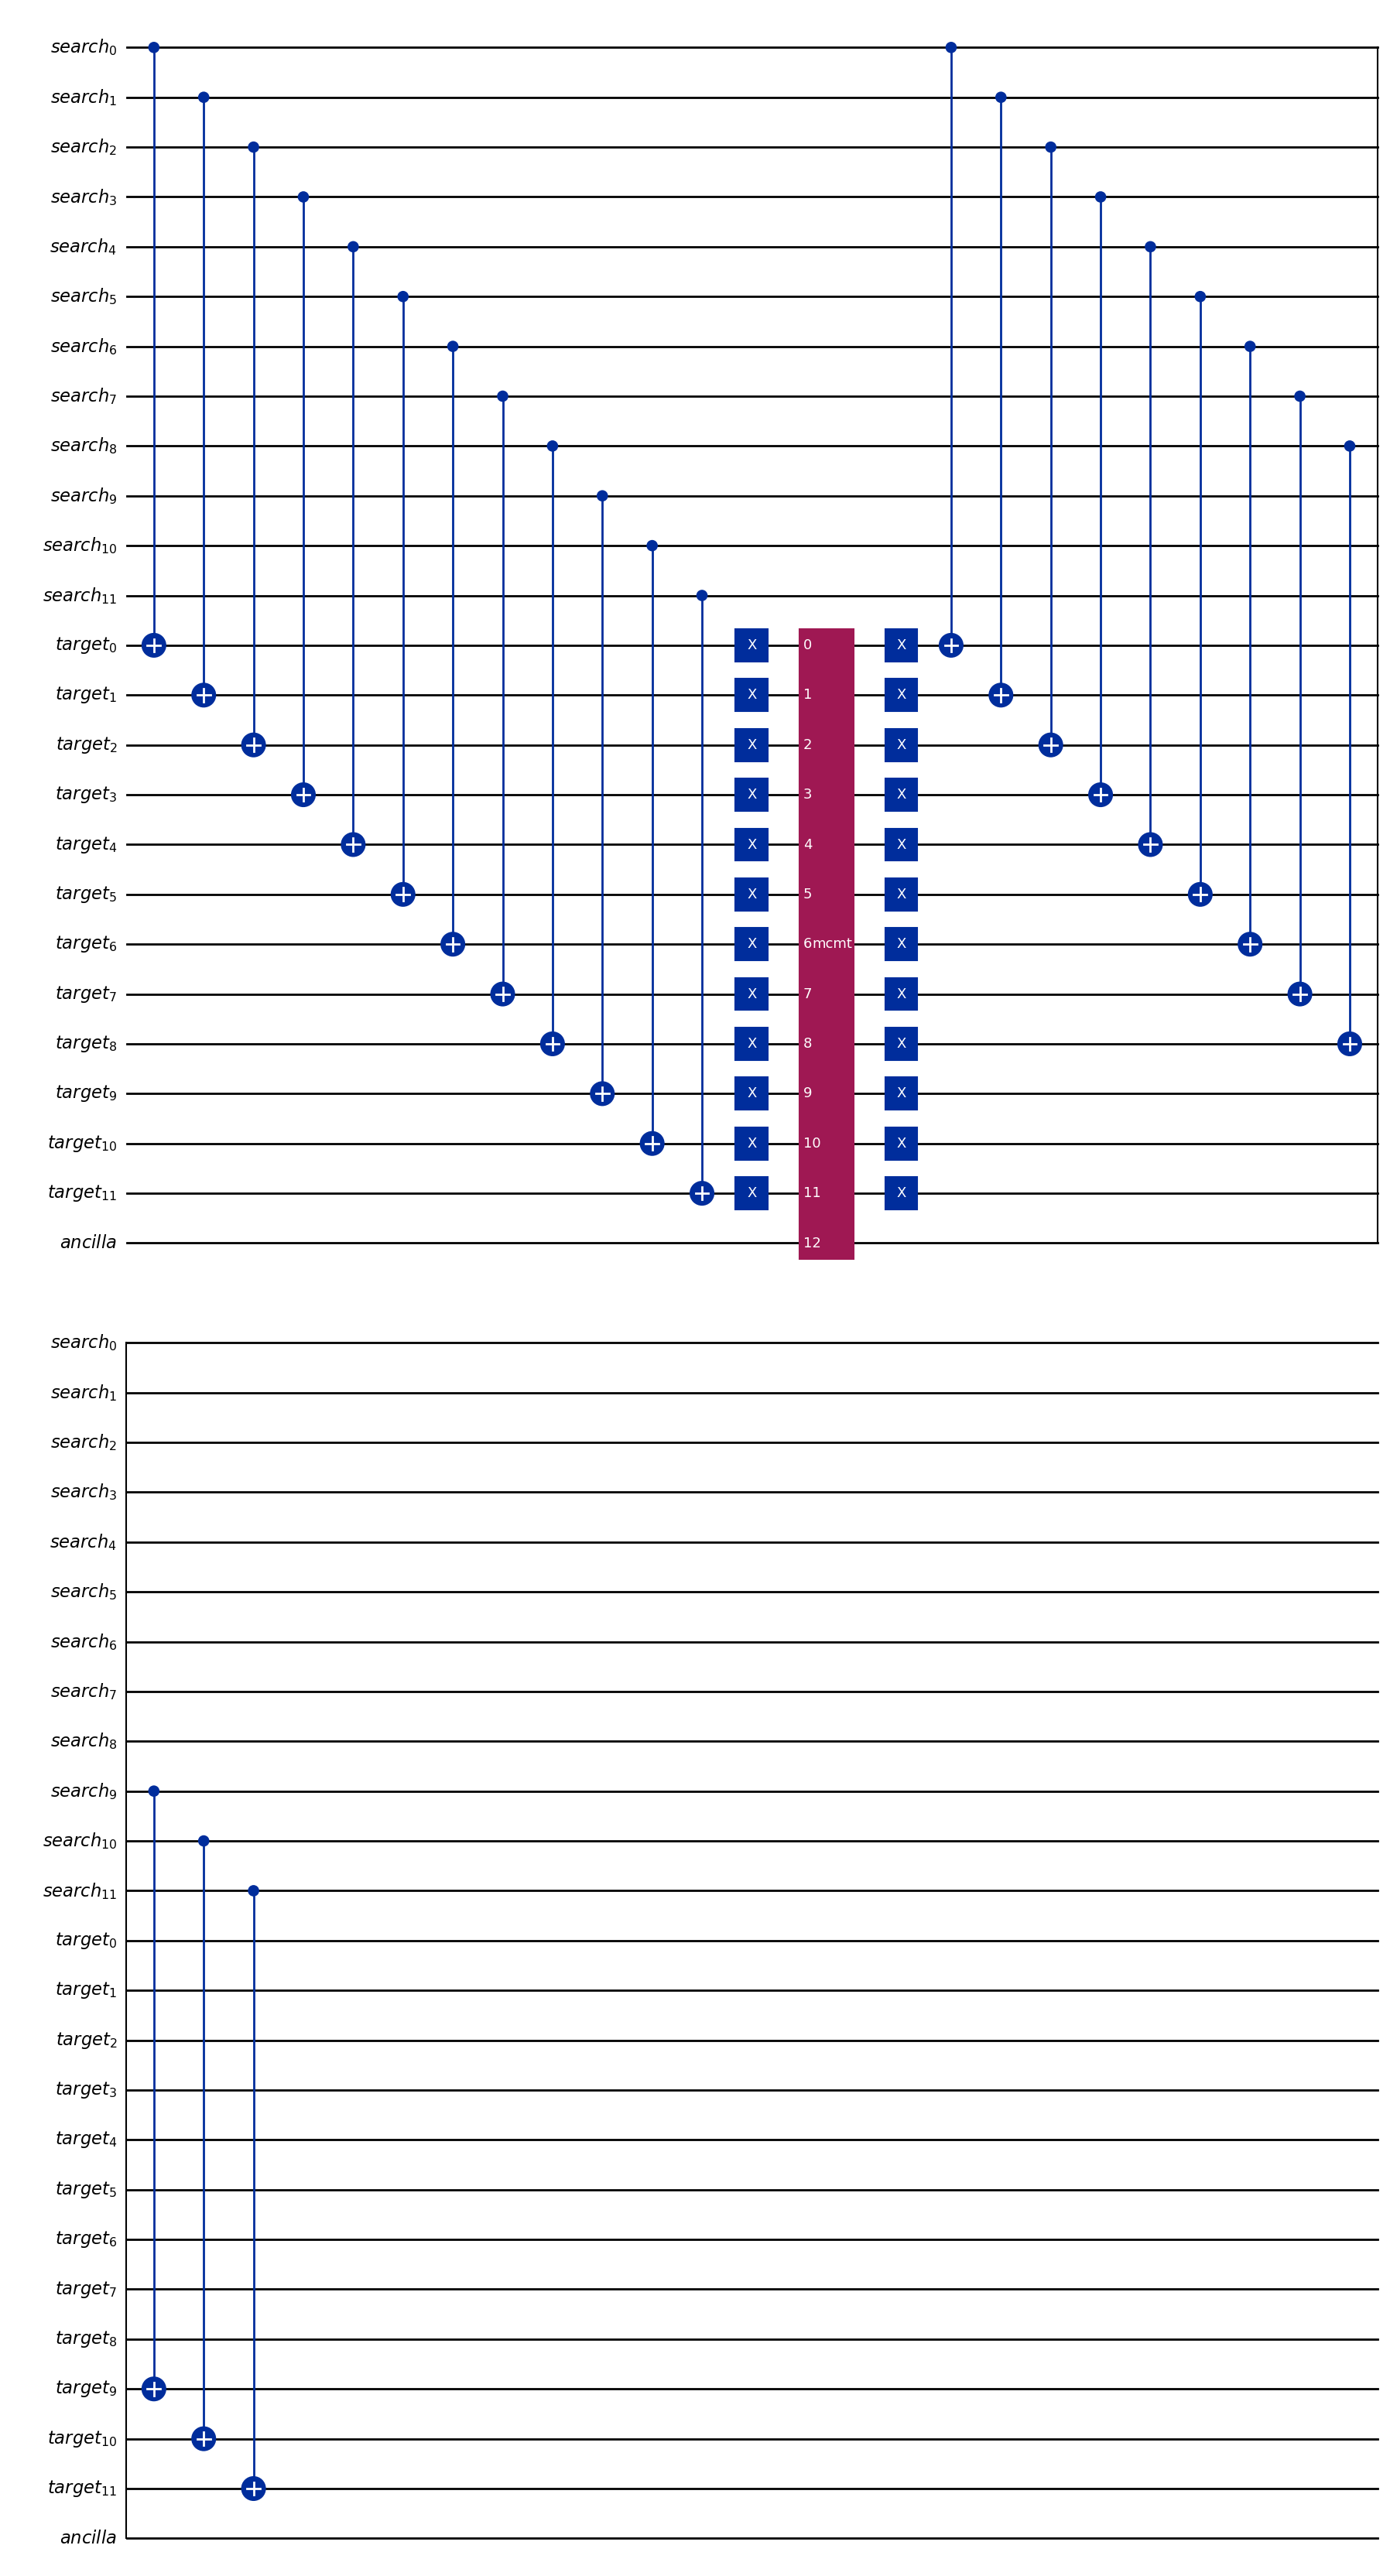


## 2. Diagrama del Circuito del Difusor


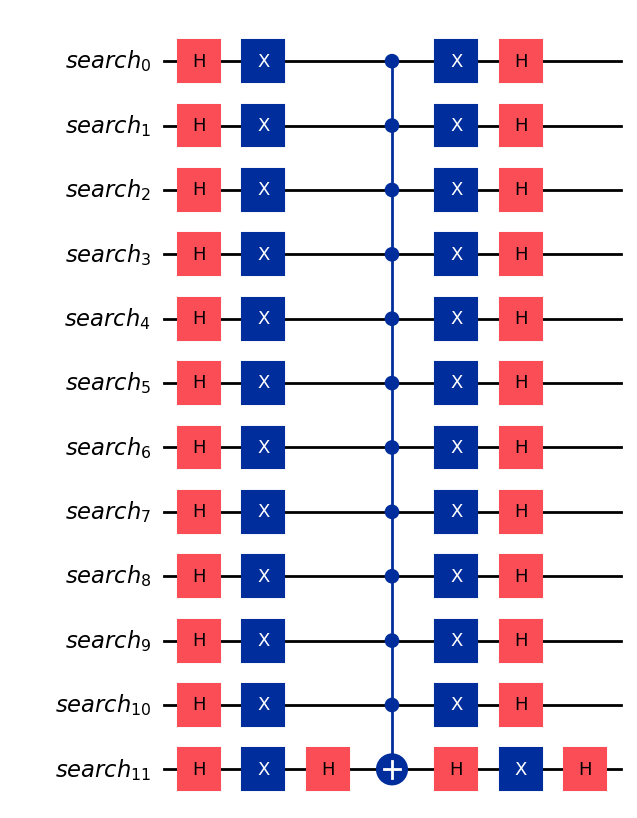

In [3]:
# 1. Crear el circuito del Oráculo
oracle_circuit = get_oracle()

print("## 1. Diagrama del Circuito del Oráculo")
# El estilo 'iqx' es moderno y claro
display(oracle_circuit.draw('mpl', style='iqx'))


# 2. Crear el circuito del Difusor
diffuser_circuit = get_diffuser()

print("\n## 2. Diagrama del Circuito del Difusor")
display(diffuser_circuit.draw('mpl', style='iqx'))

In [4]:
# --- Iteraciones de Grover ---
for _ in range(iterations):
    qc.barrier()
    qc.compose(oracle, inplace=True)
    qc.barrier()
    qc.compose(diffuser, inplace=True)

# --- Medición explícita (¡IMPORTANTE para SamplerV2!) ---
qc.barrier()
qc.measure(search_reg, c_reg)

# --- Ejecución ---
counts = None
try:
    if use_real_backend:
        service = QiskitRuntimeService()
        backend = service.get_backend(backend_name)
        print(f"Backend seleccionado: {backend.name}")
        t_qc = transpile(qc, backend, optimization_level=3)
        sampler = SamplerV2(backend)
        sampler.options.default_shots = shots
        job = sampler.run([t_qc])
        result = job.result()
        counts = result[0].data.meas.get_counts()
    else:
        raise RuntimeError("Forzando emulación local.")  # Simulación local forzada
except Exception as e:
    print(f"[!] Error con backend real: {e}\n→ Usando emulación local.")
    backend = AerSimulator()
    t_qc = transpile(qc, backend, optimization_level=2)
    result = backend.run(t_qc, shots=shots).result()
    counts = result.get_counts()

# --- Procesamiento y visualización ---
if counts is not None:
    processed_counts = {key[::-1]: val for key, val in counts.items()}
    target_bin_str = format(target_number, f'0{n}b')
    print(f"\nResultado esperado (binario): {target_bin_str}")
    top = sorted(processed_counts.items(), key=lambda x: x[1], reverse=True)[:5]
    print("Top 5 resultados:")
    for state, count in top:
        print(f"  - {state} → {int(state, 2)}: {count} ({(count/shots)*100:.2f}%)")
    plot_histogram(processed_counts, title=f"Grover Search: Marked {target_number}")
else:
    print("[!] No se obtuvieron resultados.")

Backend seleccionado: ibm_brisbane
[!] Error con backend real: Instruction measure is already in the target
→ Usando emulación local.

Resultado esperado (binario): 010011010010
Top 5 resultados:
  - 010010110010 → 1202: 483 (47.17%)
  - 100110010010 → 2450: 3 (0.29%)
  - 111100110001 → 3889: 3 (0.29%)
  - 110101010111 → 3415: 3 (0.29%)
  - 001111011001 → 985: 2 (0.20%)


Buscando 1234 en 4096 elementos. Iteraciones: 50
Backend seleccionado: ibm_brisbane
[!] Error con backend real: Instruction measure is already in the target
→ Usando emulación local.


c:\Users\USUARIO\Desktop\STEVEN ESCRITORIO\UROSARIO\3er SEMESTRE\Tesis\AlgoritmoGR\.tesis\Lib\site-packages\qiskit_ibm_provider\api\session.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources



Resultado esperado (binario): 010011010010
Top 5 resultados:
  - 010011010010 → 1234: 517 (50.49%)
  - 100010001011 → 2187: 3 (0.29%)
  - 111101001010 → 3914: 3 (0.29%)
  - 010011010011 → 1235: 3 (0.29%)
  - 101001010001 → 2641: 2 (0.20%)


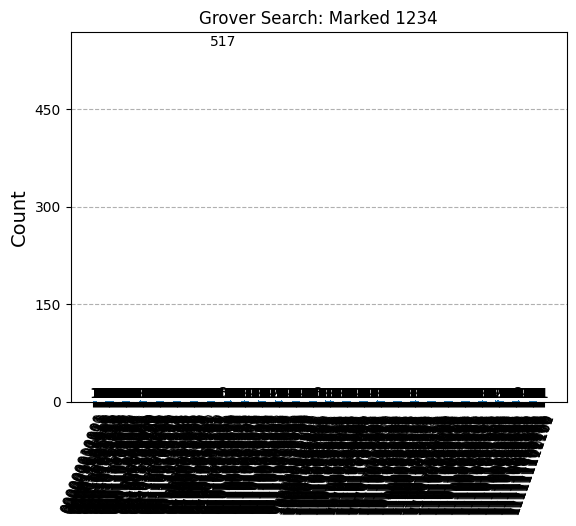

In [1]:
import math
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import ZGate, MCMT
from qiskit.visualization import plot_histogram

# Importaciones para Primitives y Backend
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2

# --- Parámetros principales ---
n = 12  # Qubits → 25 totales (12+12+1)
N = 2**n
target_number = 1234  # Entre 0 y 4095
shots = 1024
use_real_backend = True
backend_name = "ibm_brisbane"

# --- Iteraciones Grover ---
# Fórmula más robusta para el cálculo de iteraciones
iterations = math.floor(math.pi / 4 * math.sqrt(N))
print(f"Buscando {target_number} en {N} elementos. Iteraciones: {iterations}")

# --- Registros cuánticos ---
search_reg = QuantumRegister(n, name='search')
target_reg = QuantumRegister(n, name='target')
ancilla = QuantumRegister(1, name='ancilla')
# El registro clásico se necesita para la simulación local, pero no para la medición explícita con SamplerV2
c_reg = ClassicalRegister(n, name='result')
qc = QuantumCircuit(search_reg, target_reg, ancilla) # Creamos el circuito sin el c_reg inicialmente

# --- Inicialización ---
target_bits = format(target_number, f'0{n}b')[::-1]
for i, bit in enumerate(target_bits):
    if bit == '1':
        qc.x(target_reg[i])
qc.barrier()
qc.h(search_reg)
qc.x(ancilla)
qc.h(ancilla)
qc.barrier()

# --- Oráculo MCMT ---
def get_oracle():
    """Construye el oráculo usando la descomposición H-MCX-H para la MCZ."""
    oracle_qc = QuantumCircuit(search_reg, target_reg, ancilla, name="Oracle")
    
    # Parte 1: Comparación
    for i in range(n):
        oracle_qc.cx(search_reg[i], target_reg[i])
    
    oracle_qc.x(target_reg)
    
    # --- INICIO DE LA CORRECCIÓN ---
    # Reemplazamos la línea oracle_qc.mcz(target_reg, ancilla[0])
    # por su implementación estándar y compatible:
    
    # 1. Aplicar Hadamard al qubit objetivo (ancilla)
    oracle_qc.h(ancilla[0])
    # 2. Aplicar la puerta X multi-controlada
    oracle_qc.mcx(target_reg, ancilla[0])
    # 3. Aplicar Hadamard de nuevo para completar la Z
    oracle_qc.h(ancilla[0])
    
    # --- FIN DE LA CORRECCIÓN ---
    
    oracle_qc.x(target_reg)
    
    # Parte 3: Des-cómputo
    for i in range(n):
        oracle_qc.cx(search_reg[i], target_reg[i])
        
    return oracle_qc

# --- Difusor ---
def get_diffuser():
    qc_diff = QuantumCircuit(search_reg, name="Diffuser")
    qc_diff.h(search_reg)
    qc_diff.x(search_reg)
    qc_diff.h(search_reg[-1])
    qc_diff.mcx(search_reg[:-1], search_reg[-1])
    qc_diff.h(search_reg[-1])
    qc_diff.x(search_reg)
    qc_diff.h(search_reg)
    return qc_diff

oracle = get_oracle()
diffuser = get_diffuser()

# --- Iteraciones de Grover ---
for _ in range(iterations):
    qc.barrier()
    qc.compose(oracle, inplace=True)
    qc.barrier()
    qc.compose(diffuser, inplace=True)

# --- Medición ---
# !!! ESTA LÍNEA ES LA CAUSA DEL ERROR Y DEBE SER ELIMINADA PARA SamplerV2 !!!
# qc.barrier()
# qc.measure(search_reg, c_reg)
# SamplerV2 se encarga de la medición. No la añadimos al circuito.
# --- El resto de tu código anterior (parámetros, oráculo, difusor, etc.) está perfecto ---
# ...
# qc se construye con las iteraciones de Grover, pero SIN mediciones.
# ...

# --- Ejecución ---
counts = None
try:
    if use_real_backend:
        service = QiskitRuntimeService()
        backend = service.get_backend(backend_name)
        print(f"Backend seleccionado: {backend.name}")

        # Transpilamos el circuito PURO (sin mediciones)
        t_qc = transpile(qc, backend, optimization_level=3)
        
        sampler = SamplerV2(backend)
        sampler.options.default_shots = shots
        
        # --- INICIO DE LA CORRECCIÓN ---
        # Ejecutamos el circuito transpiliado SIN mediciones.
        # El Sampler se encargará de añadirlas.
        job = sampler.run([t_qc])
        # --- FIN DE LA CORRECCIÓN ---
        
        result = job.result()
        pub_result = result[0]
        
        # Procesamos los resultados del SamplerV2
        bitstrings = [f"{i:0{n}b}" for i in pub_result.data.meas.get_shots()]
        counts = {}
        for bs in bitstrings:
            counts[bs] = counts.get(bs, 0) + 1
            
    else:
        raise RuntimeError("Forzando emulación local.")

except Exception as e:
    print(f"[!] Error con backend real: {e}\n→ Usando emulación local.")
    backend = AerSimulator()
    
    # Para el simulador local SÍ necesitamos añadir la medición manualmente
    # si usamos el método backend.run()
    qc.add_register(c_reg) # Aseguramos que el registro clásico esté
    qc.measure(search_reg, c_reg)
    
    t_qc = transpile(qc, backend, optimization_level=2)
    result = backend.run(t_qc, shots=shots).result()
    counts = result.get_counts()

# --- Procesamiento y visualización (tu código aquí es correcto) ---
if counts is not None:
    # El procesamiento de 'counts' puede variar un poco, así que unificamos
    if use_real_backend and not isinstance(next(iter(counts.keys())), str):
         # Si las claves son enteros (del Sampler), las convertimos a binario
        processed_counts = {format(k, f'0{n}b'): v for k, v in counts.items()}
    elif not use_real_backend:
        # El simulador devuelve las claves invertidas (little-endian)
        processed_counts = {key[::-1]: val for key, val in counts.items()}
    else:
        processed_counts = counts

    target_bin_str = format(target_number, f'0{n}b')
    print(f"\nResultado esperado (binario): {target_bin_str}")
    
    top = sorted(processed_counts.items(), key=lambda x: x[1], reverse=True)[:5]
    print("Top 5 resultados:")
    for state, count in top:
        print(f"  - {state} → {int(state, 2)}: {count} ({(count/shots)*100:.2f}%)")
    
    display(plot_histogram(processed_counts, title=f"Grover Search: Marked {target_number}"))
else:
    print("[!] No se obtuvieron resultados.")